# Coordinate Frame Transforms

Satellite astrodynamics requires working in several coordinate reference frames. The three most common are:

- **GCRF** (Geocentric Celestial Reference Frame) — An Earth-centered inertial frame. Equations of motion are simplest in this frame because it does not rotate with the Earth. Used for orbit propagation, conjunction analysis, and any dynamics computation.

- **ITRF** (International Terrestrial Reference Frame) — An Earth-centered, Earth-fixed frame that rotates with the Earth. Ground station positions, GPS coordinates, and geodetic quantities (latitude, longitude, altitude) are expressed in this frame.

- **TEME** (True Equator, Mean Equinox) — A quasi-inertial frame that is the native output of the SGP4 orbit propagator used with Two-Line Element sets (TLEs). It accounts for precession and a simplified nutation model but not the full IAU reduction. Positions from SGP4 must be rotated out of TEME before they can be compared with GCRF or ITRF data.

## How are these frames actually defined?

GCRF and ITRF are **realizations** of the *International Celestial Reference System* (ICRS) and the *International Terrestrial Reference System* (ITRS) respectively. A reference *system* is a mathematical definition (origin, axis orientation, time scale); a reference *frame* is a concrete realization built from a set of physically-measured fiducial points. The distinction matters because the frames drift slightly over time as new measurements refine the positions of the fiducial points.

### GCRF / GCRS — fixed to distant quasars

The **GCRS** (Geocentric Celestial Reference System) is a non-rotating, kinematically non-rotating, Earth-centered inertial system. Its axes are fixed with respect to **extragalactic radio sources** — mostly distant quasars — whose positions are measured by **Very Long Baseline Interferometry (VLBI)** using a globally distributed network of radio telescopes.

The practical realization is the **ICRF** (International Celestial Reference Frame), currently ICRF3 (adopted by the IAU in 2018), which is a catalog of ~4500 radio-source positions measured to milliarcsecond accuracy. GCRS/GCRF axes are aligned with these quasars — effectively "fixed stars at infinity" — and because quasars are billions of light-years away, they exhibit no detectable proper motion over human timescales. This gives GCRF the closest thing to a truly inertial reference that exists.

The GCRS origin is the **geocenter** (Earth's center of mass), with the standard relativistic metric of general relativity in effect. The "geocentric" qualifier distinguishes it from the **BCRF** (Barycentric Celestial Reference Frame) whose origin is the solar system barycenter.

### ITRF / ITRS — fixed to Earth's crust

The **ITRS** (International Terrestrial Reference System) is a rotating, Earth-centered, Earth-fixed system. Its axes are fixed to points *on the Earth's surface* — specifically, to a globally distributed network of **geodetic tracking stations** whose positions and velocities are continuously measured by four space-geodetic techniques:

- **GNSS** (GPS, GLONASS, Galileo, BeiDou) — ~500 stations
- **VLBI** (the same radio telescopes that define ICRF) — several dozen
- **SLR** (Satellite Laser Ranging) — a few dozen
- **DORIS** (Doppler orbit determination from a French radio-beacon network) — ~60 stations

The **ITRF** (the realization of ITRS) is computed by the IERS by combining observations from all four techniques, solving for station positions and velocities that best fit the data. Successive realizations (ITRF2000, ITRF2008, ITRF2014, ITRF2020, ...) refine the frame as more data accumulates. Station velocities are included because continental plates move at centimeters per year, so the "Earth-fixed" frame is only fixed on the scale of decades.

Key points:

- **Origin**: Earth's center of mass (geocenter), determined from satellite tracking.
- **Orientation**: Aligned with Earth's crust such that the time-averaged "horizontal" tectonic motion over the whole globe is zero (the "no-net-rotation" condition).
- **Z-axis**: The IERS Reference Pole, close to the mean Earth rotation axis (polar motion offsets are at the 0.3 arcsecond level).
- **X-axis**: Through the IERS Reference Meridian, close to the historical Greenwich meridian (but ~5 m off, because the IRM is defined from VLBI/GPS-computed station positions, not the brass strip at Greenwich).

### Why two frames? Why the transform matters

The Earth rotates approximately once per sidereal day relative to GCRF, so a point fixed in ITRF (say, a GPS station) traces out a nearly-circular path in GCRF. Converting between the two requires accounting for:

1. **Polar motion** — the ~10 meter wobble of the Earth rotation axis relative to the crust (Chandler wobble, annual term, drift)
2. **Earth rotation** — the ~15°/hr daily rotation, parameterized by the Earth Rotation Angle (ERA) or GAST, with small corrections from **UT1−UTC** (the Earth rotates at slightly non-constant speed due to atmospheric angular momentum, ocean tides, etc.)
3. **Precession and nutation** — the ~26,000-year wobble of Earth's rotation axis due to Sun/Moon torques, plus ~18.6-year and smaller nutation terms

All three effects are measured continuously by IERS and published as **Earth Orientation Parameters** (EOP): polar motion (xp, yp), UT1−UTC, and nutation corrections (dX, dY). satkit downloads EOP automatically via `sk.utils.update_datafiles()` and applies them in the full ITRF↔GCRF transforms.

## The quaternion API

All frame rotations in satkit are represented as unit quaternions. Applying a rotation to a 3-vector is done with the `*` operator: `v_out = q * v_in`.

This tutorial demonstrates the rotation functions in `satkit.frametransform`.

In [1]:
import ssl, certifi
# Point urllib at certifi's CA bundle so cartopy can download Natural Earth
# shapefiles over HTTPS without hitting macOS's stricter cert store.
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import satkit as sk
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa: F401
plt.style.use(["science", "no-latex", "../satkit.mplstyle"])
%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings("ignore", "Downloading")

## Basic Frame Rotations

The `satkit.frametransform` module provides quaternion rotation functions between the major frames. Each function takes a time (or array of times) and returns the corresponding quaternion(s).

| Function | Rotation |
|---|---|
| `qitrf2gcrf(t)` | ITRF -> GCRF (full IAU-2006) |
| `qgcrf2itrf(t)` | GCRF -> ITRF (full IAU-2006) |
| `qitrf2gcrf_approx(t)` | ITRF -> GCRF (approx., ~1 arcsec) |
| `qgcrf2itrf_approx(t)` | GCRF -> ITRF (approx., ~1 arcsec) |
| `qteme2gcrf(t)` | TEME -> GCRF |
| `qteme2itrf(t)` | TEME -> ITRF |

Let's start with a concrete example: rotating a ground station's ITRF position into the GCRF inertial frame.

In [2]:
# Define a ground station using geodetic coordinates
station = sk.itrfcoord(latitude_deg=42.0, longitude_deg=-71.0, altitude=100)
print(f'Station ITRF position: {station}')
print(f'ITRF Cartesian vector (m): {station.vector}')

# Pick a specific time
t = sk.time(2024, 6, 15, 12, 0, 0)

# Get the ITRF -> GCRF rotation quaternion at this time
q = sk.frametransform.qitrf2gcrf(t)

# Rotate the ITRF position vector to GCRF
pos_gcrf = q * station.vector
print(f'\nGCRF position at {t}: {pos_gcrf}')
print(f'Position magnitude: {np.linalg.norm(pos_gcrf):.1f} m (unchanged by rotation)')


Station ITRF position: ITRFCoord(lat:  42.0000 deg, lon: -71.0000 deg, hae:  0.10 km)
ITRF Cartesian vector (m): [ 1545495.88774424 -4488445.96859007  4245670.74916175]

GCRF position at 2024-06-15T12:00:00.000000Z: [4636380.04493557 1063929.13061154 4234673.51117344]
Position magnitude: 6368706.7 m (unchanged by rotation)


Note that the magnitude of the position vector is preserved -- quaternion rotations are rigid-body rotations.

The inverse rotation (GCRF back to ITRF) should recover the original vector:

In [3]:
# Rotate back from GCRF to ITRF
q_inv = sk.frametransform.qgcrf2itrf(t)
pos_roundtrip = q_inv * pos_gcrf

print(f'Original ITRF vector:    {station.vector}')
print(f'Round-trip ITRF vector:  {pos_roundtrip}')
print(f'Difference (m):         {np.linalg.norm(pos_roundtrip - station.vector):.2e}')


Original ITRF vector:    [ 1545495.88774424 -4488445.96859007  4245670.74916175]
Round-trip ITRF vector:  [ 1545495.88774424 -4488445.96859007  4245670.74916175]
Difference (m):         1.99e-09


## Approximate vs Full IAU-2006 Reduction

The full IAU-2006/2010 ITRF-GCRF rotation accounts for precession, nutation, Earth rotation angle, and polar motion using the complete IERS conventions. This is computationally expensive.

The `_approx` variants use a simplified model that omits the small high-frequency nutation terms and polar motion. The plot below shows the resulting angular error over several decades.


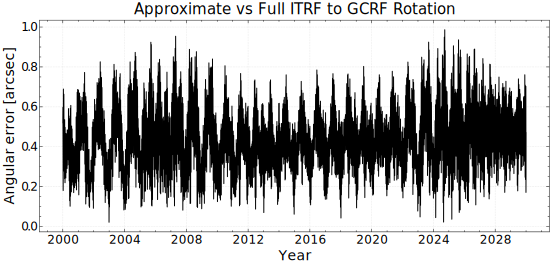

Peak error over 2000-2030: 0.986 arcsec


In [4]:
# Compare full and approximate ITRF -> GCRF rotation over a span of years
import math as m

start = sk.time(2000, 1, 1)
end = sk.time(2030, 1, 1)
duration = end - start
timearray = np.array([start + sk.duration.from_days(x)
                      for x in np.linspace(0, duration.days, 4000)])

qexact = sk.frametransform.qgcrf2itrf(timearray)
qapprox = sk.frametransform.qgcrf2itrf_approx(timearray)
qdiff = np.array([q1 * q2.conjugate for q1, q2 in zip(qexact, qapprox)])
theta_arcsec = np.array([min(q.angle, 2 * m.pi - q.angle) for q in qdiff]) * 180.0 / m.pi * 3600

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([t.as_datetime() for t in timearray], theta_arcsec, "k-", linewidth=1)
ax.set_xlabel("Year")
ax.set_ylabel("Angular error [arcsec]")
ax.set_title("Approximate vs Full ITRF to GCRF Rotation")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Peak error over {start.as_datetime().year}-{end.as_datetime().year}: '
      f'{theta_arcsec.max():.3f} arcsec')


The error stays at the arcsecond level, which is more than sufficient for ground-track plotting, pass prediction, and other applications that do not require sub-arcsecond accuracy. For high-precision orbit determination, use the full reduction.


## SGP4 Output Frame: TEME to GCRF Pipeline

The SGP4 propagator outputs position and velocity in the TEME frame, which is specific to the SGP4/TLE mathematical model. To use SGP4 results alongside data in standard frames, they must be rotated.

The typical pipeline is:
- **TEME -> GCRF**: Use `qteme2gcrf` for inertial comparisons or further orbit analysis
- **TEME -> ITRF**: Use `qteme2itrf` to compute ground tracks, visibility, or geodetic sub-satellite points

Below, we propagate the ISS using SGP4 and convert the results to both GCRF and ITRF.

In [5]:
# ISS TLE (example epoch)
line1 = '1 25544U 98067A   24167.50000000  .00016717  00000-0  10270-3 0  9002'
line2 = '2 25544  51.6400 200.0000 0001000  90.0000 270.0000 15.49000000400000'
tle = sk.TLE.from_lines([line1, line2])
print(f'TLE epoch: {tle.epoch}')

# Propagate at a single time near epoch
t = tle.epoch
pos_teme, vel_teme = sk.sgp4(tle, t)
print(f'\nTEME position (m): {pos_teme}')
print(f'TEME velocity (m/s): {vel_teme}')


TLE epoch: 2024-06-15T12:00:00.000000Z

TEME position (m): [-6391305.42501464 -2317595.87947919   -10261.67315596]
TEME velocity (m/s): [ 1618.29571995 -4467.83052083  6008.27561488]


In [6]:
# Rotate TEME position and velocity to GCRF
q_teme2gcrf = sk.frametransform.qteme2gcrf(t)
pos_gcrf = q_teme2gcrf * pos_teme
vel_gcrf = q_teme2gcrf * vel_teme
print(f'GCRF position (m):   {pos_gcrf}')
print(f'GCRF velocity (m/s): {vel_gcrf}')

# Rotate TEME position to ITRF. At this point we have a Cartesian
# (X, Y, Z) vector in the Earth-fixed frame — the three numbers describe
# where the satellite is relative to Earth's centre, with +X through the
# Greenwich meridian and +Z along the rotation axis.
q_teme2itrf = sk.frametransform.qteme2itrf(t)
pos_itrf = q_teme2itrf * pos_teme
print(f'\nITRF Cartesian (m):  {pos_itrf}')

# `sk.itrfcoord` wraps the ITRF Cartesian vector and exposes geodetic
# coordinates. The distinction matters:
#
#   * Cartesian  — (X, Y, Z) in meters, Earth-fixed. What the rotation
#                  actually gives us. Simple and unambiguous but not how
#                  humans think about "where on Earth".
#
#   * Geodetic   — (latitude, longitude, altitude) on the WGS-84
#                  reference ellipsoid. Latitude is the angle between
#                  the *ellipsoid normal* and the equatorial plane
#                  (NOT the angle from the centre, which would be
#                  "geocentric latitude"). Altitude is the perpendicular
#                  distance above the ellipsoid surface. This is the
#                  convention used by GPS, almost all maps, and by
#                  aviation / surveying standards.
#
# `sk.itrfcoord(pos_itrf)` auto-detects that it was given a 3-vector and
# converts Cartesian → geodetic using the WGS-84 ellipsoid parameters.
subsatpoint = sk.itrfcoord(pos_itrf)
print(f'Sub-satellite point: {subsatpoint}')
print(f'  latitude:  {subsatpoint.latitude_deg:+8.4f}° (geodetic, WGS-84)')
print(f'  longitude: {subsatpoint.longitude_deg:+8.4f}°')
print(f'  altitude:  {subsatpoint.altitude / 1e3:.2f} km above WGS-84 ellipsoid')

GCRF position (m):   [-6.40388933e+06 -2.28261199e+06  5.00075287e+03]
GCRF velocity (m/s): [ 1608.08163108 -4476.40579544  6004.63413429]

ITRF Cartesian (m):  [-2944893.37251981  6127612.83232683   -10246.94729345]
Sub-satellite point: ITRFCoord(lat:  -0.0869 deg, lon: 115.6687 deg, hae: 420.40 km)
  latitude:   -0.0869° (geodetic, WGS-84)
  longitude: +115.6687°
  altitude:  420.40 km above WGS-84 ellipsoid


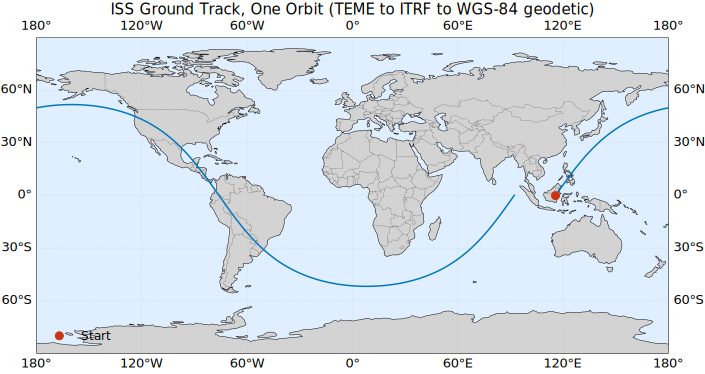

In [7]:
# Propagate over one full orbit and plot the ground track
import cartopy.crs as ccrs
import cartopy.feature as cfeature

period_minutes = 1440 / tle.mean_motion  # period in minutes
prop_minutes = np.linspace(0, period_minutes, 500)
prop_times = [tle.epoch + sk.duration.from_minutes(float(m)) for m in prop_minutes]

# TEME (SGP4 output) -> ITRF Cartesian -> WGS-84 geodetic (lat, lon)
lats = []
lons = []
for t in prop_times:
    pos_teme, _ = sk.sgp4(tle, t)
    pos_itrf = sk.frametransform.qteme2itrf(t) * pos_teme
    coord = sk.itrfcoord(pos_itrf)  # Cartesian -> geodetic via WGS-84
    lats.append(coord.latitude_deg)
    lons.append(coord.longitude_deg)

lon_arr = np.array(lons)
lat_arr = np.array(lats)

# Break the ground track at date-line crossings so matplotlib doesn't
# draw a long horizontal line across the map when the satellite wraps
# from +180 deg to -180 deg.
breaks = np.where(np.abs(np.diff(lon_arr)) > 180)[0] + 1
lon_segs = np.split(lon_arr, breaks)
lat_segs = np.split(lat_arr, breaks)

fig, ax = plt.subplots(figsize=(11, 5.5),
                       subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="#dfefff")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")

for lo, la in zip(lon_segs, lat_segs):
    ax.plot(lo, la, linewidth=1.5, color="C0", transform=ccrs.PlateCarree())

# Mark start with a filled circle
ax.plot(lon_arr[0], lat_arr[0], "o", color="C3", markersize=8,
        transform=ccrs.PlateCarree(), label="Start")
ax.set_title("ISS Ground Track, One Orbit (TEME to ITRF to WGS-84 geodetic)")
ax.set_global()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Summary

The `satkit.frametransform` module provides all the rotations needed to convert between the standard coordinate frames used in satellite astrodynamics:

- Use `qitrf2gcrf` / `qgcrf2itrf` for converting between Earth-fixed and inertial frames (full IAU-2006 accuracy)
- Use the `_approx` variants when sub-arcsecond accuracy is not required
- Use `qteme2gcrf` and `qteme2itrf` to convert SGP4/TLE outputs to standard frames
- All functions accept both scalar times and arrays, returning quaternion(s) accordingly
- Apply rotations to 3-vectors with the `*` operator: `v_out = q * v_in`